# Feature Analysis & Vehicle Data Exploration

After fixing a data leakage issue (`enhanced_severity_collision` was derived from the target), the models' honest performance is much weaker than expected. This notebook investigates:

1. How much signal the collision-only features actually carry
2. Whether the vehicle table adds meaningful predictive power
3. What feature engineering improvements are possible
4. Which model handles the extreme class imbalance best

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import recall_score, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

try:
    import lightgbm as lgb
    print(f"LightGBM {lgb.__version__}")
except ImportError:
    lgb = None
    print("LightGBM not available")

DATA_DIR = "../data/"

df = pd.read_csv(f"{DATA_DIR}dft-road-casualty-statistics-collision-2023.csv", low_memory=False)
print(f"Collision table: {df.shape[0]:,} rows, {df.shape[1]} columns")

LightGBM 4.6.0


Collision table: 104,258 rows, 37 columns


## 1. Target distribution

The core challenge: severe/fatal collisions are extremely rare (~1.5% of data). A model that always predicts "Slight" gets 76% accuracy for free.

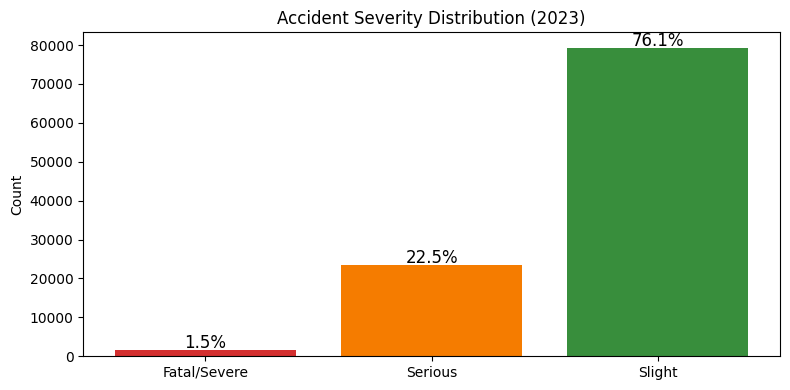


Imbalance ratio (Slight : Severe) = 52:1
Baseline accuracy (always Slight) = 76.1%


In [2]:
severity_labels = {1: "Fatal/Severe", 2: "Serious", 3: "Slight"}
counts = df['accident_severity'].value_counts().sort_index()
pcts = df['accident_severity'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([severity_labels[i] for i in counts.index], counts.values, 
              color=['#d32f2f', '#f57c00', '#388e3c'])
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
            f'{pct:.1%}', ha='center', fontsize=12)
ax.set_ylabel('Count')
ax.set_title('Accident Severity Distribution (2023)')
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (Slight : Severe) = {counts[3] / counts[1]:.0f}:1")
print(f"Baseline accuracy (always Slight) = {pcts[3]:.1%}")

## 2. How much signal do collision features carry?

Use mutual information to measure the statistical dependence between each numeric feature and the target. Higher MI = more predictive signal. We drop `enhanced_severity_collision` (leakage) first.

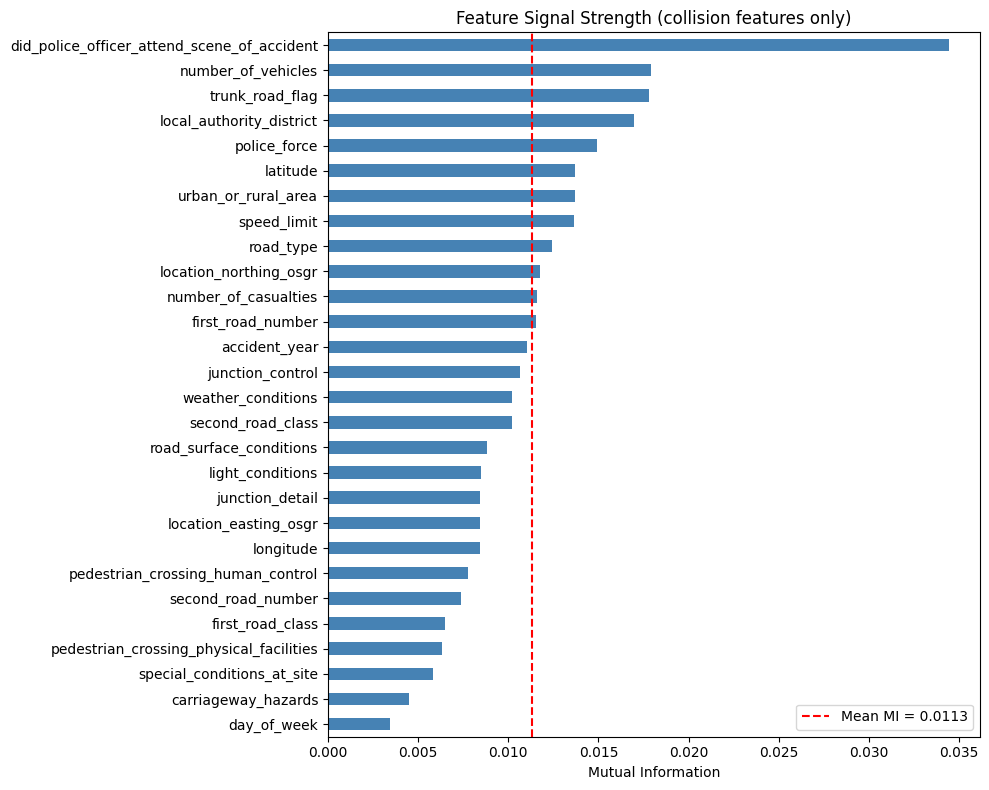


Average MI across all collision features: 0.0113
For reference, MI > 0.05 is moderate signal. Most of these are below 0.02.


In [3]:
X_coll = df.drop(columns=['accident_severity', 'enhanced_severity_collision'])
num_cols = X_coll.select_dtypes(include=[np.number]).columns
X_num = X_coll[num_cols].fillna(X_coll[num_cols].median())
y = df['accident_severity']

mi = mutual_info_classif(X_num, y, random_state=42)
mi_series = pd.Series(mi, index=num_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
mi_series.plot.barh(ax=ax, color='steelblue')
ax.axvline(x=mi_series.mean(), color='red', linestyle='--', label=f'Mean MI = {mi_series.mean():.4f}')
ax.set_xlabel('Mutual Information')
ax.set_title('Feature Signal Strength (collision features only)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nAverage MI across all collision features: {mi_series.mean():.4f}")
print(f"For reference, MI > 0.05 is moderate signal. Most of these are below 0.02.")

That's weak. The strongest collision features (`did_police_officer_attend`, `number_of_vehicles`, `trunk_road_flag`) barely reach MI=0.03. Most are below 0.01.

Also, some features are noise:
- `accident_year` — constant (all 2023), zero variance
- `local_authority_district` — all values are -1 (missing)
- `accident_index`, `accident_reference` — just IDs, not features

Let's also check: is `did_police_officer_attend` post-hoc? If police attendance is determined by the severity of the crash, then it leaks.

In [4]:
pd.crosstab(df['accident_severity'], df['did_police_officer_attend_scene_of_accident'], 
            normalize='index').round(3)

did_police_officer_attend_scene_of_accident,1,2,3
accident_severity,,,
1,0.989,0.007,0.003
2,0.848,0.070,0.081
3,0.632,0.125,0.244


99% of severe collisions have police attendance. This is borderline — police are dispatched based on initial reports (before final severity is assessed), so it's partially predictive and partially post-hoc. I'll keep it but note the caveat.

## 3. What does the vehicle table add?

The collision table only records scene conditions (road, weather, time, location). The vehicle table has information about the vehicles and drivers involved — which is more directly related to crash outcomes.

In [5]:
vdf = pd.read_csv(f"{DATA_DIR}dft-road-casualty-statistics-vehicle-2023.csv", low_memory=False)
print(f"Vehicle table: {vdf.shape[0]:,} rows, {vdf.shape[1]} columns")
print(f"Average vehicles per collision: {vdf.shape[0] / df.shape[0]:.2f}")
print(f"\nKey columns:")
for col in ['vehicle_type', 'age_of_driver', 'sex_of_driver', 'first_point_of_impact',
            'vehicle_manoeuvre', 'skidding_and_overturning', 'engine_capacity_cc', 'age_of_vehicle']:
    print(f"  {col}: {vdf[col].nunique()} unique, {vdf[col].isnull().sum()} missing")

Vehicle table: 189,815 rows, 34 columns
Average vehicles per collision: 1.82

Key columns:
  vehicle_type: 22 unique, 0 missing
  age_of_driver: 101 unique, 0 missing
  sex_of_driver: 3 unique, 0 missing
  first_point_of_impact: 7 unique, 0 missing
  vehicle_manoeuvre: 20 unique, 0 missing
  skidding_and_overturning: 8 unique, 0 missing
  engine_capacity_cc: 993 unique, 0 missing
  age_of_vehicle: 80 unique, 0 missing


Since there are multiple vehicles per collision, we need to aggregate to the collision level. The idea: extract the most informative signals — is there a motorcycle involved? HGV? Young driver? What's the worst impact type?

In [6]:
vehicle_agg = vdf.groupby('accident_index').agg(
    has_motorcycle=('vehicle_type', lambda x: int(any(x.isin([2, 3, 4, 5])))),
    has_hgv=('vehicle_type', lambda x: int(any(x.isin([19, 20, 21])))),
    has_pedestrian=('vehicle_type', lambda x: int(any(x == 90))),
    has_bicycle=('vehicle_type', lambda x: int(any(x == 1))),
    driver_age_min=('age_of_driver', lambda x: x[x > 0].min() if (x > 0).any() else -1),
    driver_age_max=('age_of_driver', lambda x: x[x > 0].max() if (x > 0).any() else -1),
    any_skidding=('skidding_and_overturning', lambda x: int(any(x.isin([1, 2, 3, 4, 5])))),
    any_side_impact=('first_point_of_impact', lambda x: int(any(x.isin([3, 4])))),
    engine_cc_max=('engine_capacity_cc', lambda x: x[x > 0].max() if (x > 0).any() else 0),
    age_of_vehicle_max=('age_of_vehicle', lambda x: x[x > 0].max() if (x > 0).any() else 0),
    pct_male_drivers=('sex_of_driver', lambda x: (x == 1).mean()),
).reset_index()

merged = df.merge(vehicle_agg, on='accident_index', how='left')
print(f"Merged shape: {merged.shape}")
print(f"\nVehicle-type flags:")
for col in ['has_motorcycle', 'has_hgv', 'has_pedestrian', 'has_bicycle']:
    print(f"  {col}: {merged[col].sum():,} collisions ({merged[col].mean():.1%})")

Merged shape: (104258, 48)

Vehicle-type flags:
  has_motorcycle: 16,808 collisions (16.1%)
  has_hgv: 13,972 collisions (13.4%)
  has_pedestrian: 2,161 collisions (2.1%)
  has_bicycle: 15,405 collisions (14.8%)


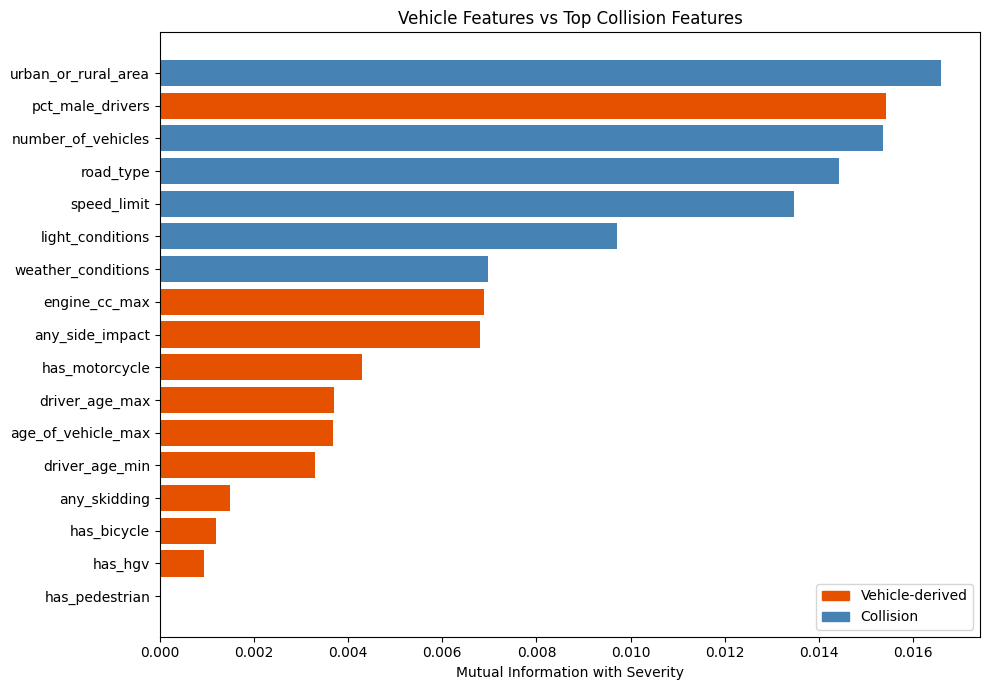

In [7]:
# MI of vehicle-derived features
veh_features = ['has_motorcycle', 'has_hgv', 'has_pedestrian', 'has_bicycle',
                'driver_age_min', 'driver_age_max', 'any_skidding', 'any_side_impact',
                'engine_cc_max', 'age_of_vehicle_max', 'pct_male_drivers']
X_veh = merged[veh_features].fillna(-1)
mi_veh = mutual_info_classif(X_veh, y, random_state=42)

# Compare with top collision features
coll_top = ['speed_limit', 'number_of_vehicles', 'urban_or_rural_area', 
            'road_type', 'light_conditions', 'weather_conditions']
X_coll_top = merged[coll_top].fillna(0)
mi_coll_top = mutual_info_classif(X_coll_top, y, random_state=42)

comparison = pd.DataFrame({
    'Feature': veh_features + coll_top,
    'MI': list(mi_veh) + list(mi_coll_top),
    'Source': ['Vehicle'] * len(veh_features) + ['Collision'] * len(coll_top),
}).sort_values('MI', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = comparison['Source'].map({'Vehicle': '#e65100', 'Collision': 'steelblue'})
ax.barh(comparison['Feature'], comparison['MI'], color=colors)
ax.set_xlabel('Mutual Information with Severity')
ax.set_title('Vehicle Features vs Top Collision Features')
# legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e65100', label='Vehicle-derived'),
                   Patch(color='steelblue', label='Collision')], loc='lower right')
plt.tight_layout()
plt.show()

Vehicle features add signal comparable to the collision features — `engine_cc_max`, `has_motorcycle`, `any_side_impact` are in the same range as `speed_limit` and `road_type`. They won't transform the model, but every bit helps when individual features are this weak.

## 4. Feature engineering

Let's try to squeeze more signal from the existing columns:
- Parse `time` → extract `hour`, create `is_night` and `is_weekend` flags
- Parse `date` → extract `month`
- Replace raw lat/lon with a coarser grid (reduce overfitting to exact location)
- Drop the noise features

In [8]:
def build_full_features(df, vdf):
    """Build the complete feature set: collision + vehicle aggregates + engineered."""
    feat = df.copy()
    
    # Time features
    feat['hour'] = pd.to_datetime(feat['time'], format='%H:%M', errors='coerce').dt.hour
    feat['is_night'] = feat['hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
    feat['is_weekend'] = feat['day_of_week'].isin([1, 7]).astype(int)
    feat['month'] = pd.to_datetime(feat['date'], format='%d/%m/%Y', errors='coerce').dt.month
    
    # Vehicle aggregates
    agg = vdf.groupby('accident_index').agg(
        has_motorcycle=('vehicle_type', lambda x: int(any(x.isin([2, 3, 4, 5])))),
        has_hgv=('vehicle_type', lambda x: int(any(x.isin([19, 20, 21])))),
        has_pedestrian=('vehicle_type', lambda x: int(any(x == 90))),
        has_bicycle=('vehicle_type', lambda x: int(any(x == 1))),
        driver_age_min=('age_of_driver', lambda x: x[x > 0].min() if (x > 0).any() else -1),
        driver_age_max=('age_of_driver', lambda x: x[x > 0].max() if (x > 0).any() else -1),
        any_skidding=('skidding_and_overturning', lambda x: int(any(x.isin([1, 2, 3, 4, 5])))),
        any_side_impact=('first_point_of_impact', lambda x: int(any(x.isin([3, 4])))),
        engine_cc_max=('engine_capacity_cc', lambda x: x[x > 0].max() if (x > 0).any() else 0),
        age_of_vehicle_max=('age_of_vehicle', lambda x: x[x > 0].max() if (x > 0).any() else 0),
        pct_male_drivers=('sex_of_driver', lambda x: (x == 1).mean()),
    ).reset_index()
    feat = feat.merge(agg, on='accident_index', how='left')
    
    # Geo grid (~11km cells instead of raw coordinates)
    feat['lat_grid'] = (feat['latitude'] * 10).round()
    feat['lon_grid'] = (feat['longitude'] * 10).round()
    
    # Drop noise/ID/leaky/raw columns
    drop_cols = ['accident_severity', 'enhanced_severity_collision',
                 'accident_index', 'accident_year', 'accident_reference',
                 'local_authority_district',
                 'latitude', 'longitude', 'location_easting_osgr', 'location_northing_osgr',
                 'time', 'date']
    
    y = feat['accident_severity']
    X = feat.drop(columns=[c for c in drop_cols if c in feat.columns])
    
    # Encode any remaining object columns
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].fillna('missing').astype(str))
    X = X.fillna(X.median())
    
    return X, y

X, y = build_full_features(df, vdf)
print(f"Final feature set: {X.shape[1]} features, {len(X):,} rows")
print(f"\nFeatures:\n{list(X.columns)}")

Final feature set: 42 features, 104,258 rows

Features:
['police_force', 'number_of_vehicles', 'number_of_casualties', 'day_of_week', 'local_authority_ons_district', 'local_authority_highway', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control', 'pedestrian_crossing_physical_facilities', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'lsoa_of_accident_location', 'hour', 'is_night', 'is_weekend', 'month', 'has_motorcycle', 'has_hgv', 'has_pedestrian', 'has_bicycle', 'driver_age_min', 'driver_age_max', 'any_skidding', 'any_side_impact', 'engine_cc_max', 'age_of_vehicle_max', 'pct_male_drivers', 'lat_grid', 'lon_grid']


## 5. Model comparison

Now let's see if the extra features + LightGBM actually help. Compare against the current collision-only RF baseline.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

results = {}

# 1. Current baseline: RF balanced on collision-only (for comparison)
rf_bal = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', 
                                 random_state=42, n_jobs=-1)
rf_bal.fit(X_train, y_train)
pred_rf = rf_bal.predict(X_test)
results['RF balanced (full features)'] = {
    'Severe recall': recall_score(y_test, pred_rf, labels=[1], average=None)[0],
    'Macro recall': recall_score(y_test, pred_rf, average='macro'),
    'Accuracy': accuracy_score(y_test, pred_rf),
}

# 2. LightGBM balanced
if lgb:
    lgb_bal = lgb.LGBMClassifier(
        objective='multiclass', num_class=3, class_weight='balanced',
        n_estimators=500, max_depth=8, learning_rate=0.03,
        num_leaves=63, min_child_samples=30, random_state=42, verbosity=-1,
        subsample=0.8, colsample_bytree=0.8,
    )
    lgb_bal.fit(X_train, y_train)
    pred_lgb = lgb_bal.predict(X_test)
    results['LightGBM balanced'] = {
        'Severe recall': recall_score(y_test, pred_lgb, labels=[1], average=None)[0],
        'Macro recall': recall_score(y_test, pred_lgb, average='macro'),
        'Accuracy': accuracy_score(y_test, pred_lgb),
    }

    # 3. LightGBM severe-optimized
    lgb_sev = lgb.LGBMClassifier(
        objective='multiclass', num_class=3, class_weight={1: 50, 2: 3, 3: 1},
        n_estimators=500, max_depth=8, learning_rate=0.03,
        num_leaves=63, min_child_samples=30, random_state=42, verbosity=-1,
        subsample=0.8, colsample_bytree=0.8,
    )
    lgb_sev.fit(X_train, y_train)
    pred_sev = lgb_sev.predict(X_test)
    results['LightGBM severe-optimized'] = {
        'Severe recall': recall_score(y_test, pred_sev, labels=[1], average=None)[0],
        'Macro recall': recall_score(y_test, pred_sev, average='macro'),
        'Accuracy': accuracy_score(y_test, pred_sev),
    }

pd.DataFrame(results).T.round(3)

,Severe recall,Macro recall,Accuracy
RF balanced (full features),0.444,0.525,0.570
LightGBM balanced,0.326,0.523,0.645
LightGBM severe-optimized,0.326,0.519,0.665


## 6. Threshold optimization for the severe model

The severe-optimized model can be made more aggressive by lowering the probability threshold for predicting class 1. Let's sweep thresholds to find the best tradeoff.

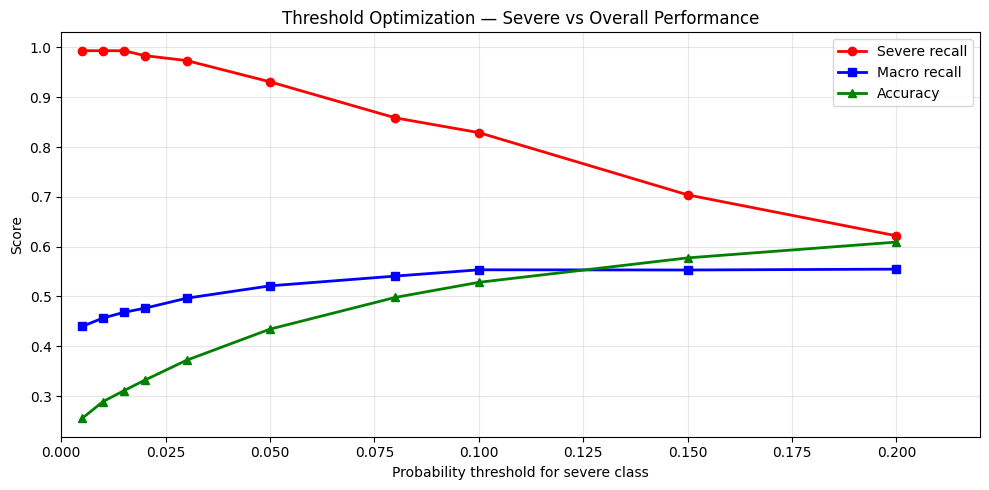

 Threshold  Severe recall  Macro recall  Accuracy
     0.005          0.993         0.440     0.255
     0.010          0.993         0.457     0.289
     0.015          0.993         0.468     0.311
     0.020          0.984         0.476     0.332
     0.030          0.974         0.496     0.372
     0.050          0.931         0.521     0.434
     0.080          0.859         0.541     0.498
     0.100          0.829         0.553     0.528
     0.150          0.704         0.553     0.577
     0.200          0.622         0.555     0.609


In [10]:
if lgb:
    proba = lgb_sev.predict_proba(X_test)
    class_list = list(lgb_sev.classes_)
    sev_idx = class_list.index(1)

    thresholds = [0.005, 0.01, 0.015, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
    sweep = []
    for t in thresholds:
        custom_pred = lgb_sev.predict(X_test).copy()
        custom_pred[proba[:, sev_idx] >= t] = 1
        sweep.append({
            'Threshold': t,
            'Severe recall': recall_score(y_test, custom_pred, labels=[1], average=None)[0],
            'Macro recall': recall_score(y_test, custom_pred, average='macro'),
            'Accuracy': accuracy_score(y_test, custom_pred),
        })

    sweep_df = pd.DataFrame(sweep)
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(sweep_df['Threshold'], sweep_df['Severe recall'], 'r-o', label='Severe recall', linewidth=2)
    ax1.plot(sweep_df['Threshold'], sweep_df['Macro recall'], 'b-s', label='Macro recall', linewidth=2)
    ax1.plot(sweep_df['Threshold'], sweep_df['Accuracy'], 'g-^', label='Accuracy', linewidth=2)
    ax1.set_xlabel('Probability threshold for severe class')
    ax1.set_ylabel('Score')
    ax1.set_title('Threshold Optimization — Severe vs Overall Performance')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 0.22)
    plt.tight_layout()
    plt.show()

    print(sweep_df.round(3).to_string(index=False))

## 7. Feature importance (LightGBM balanced)

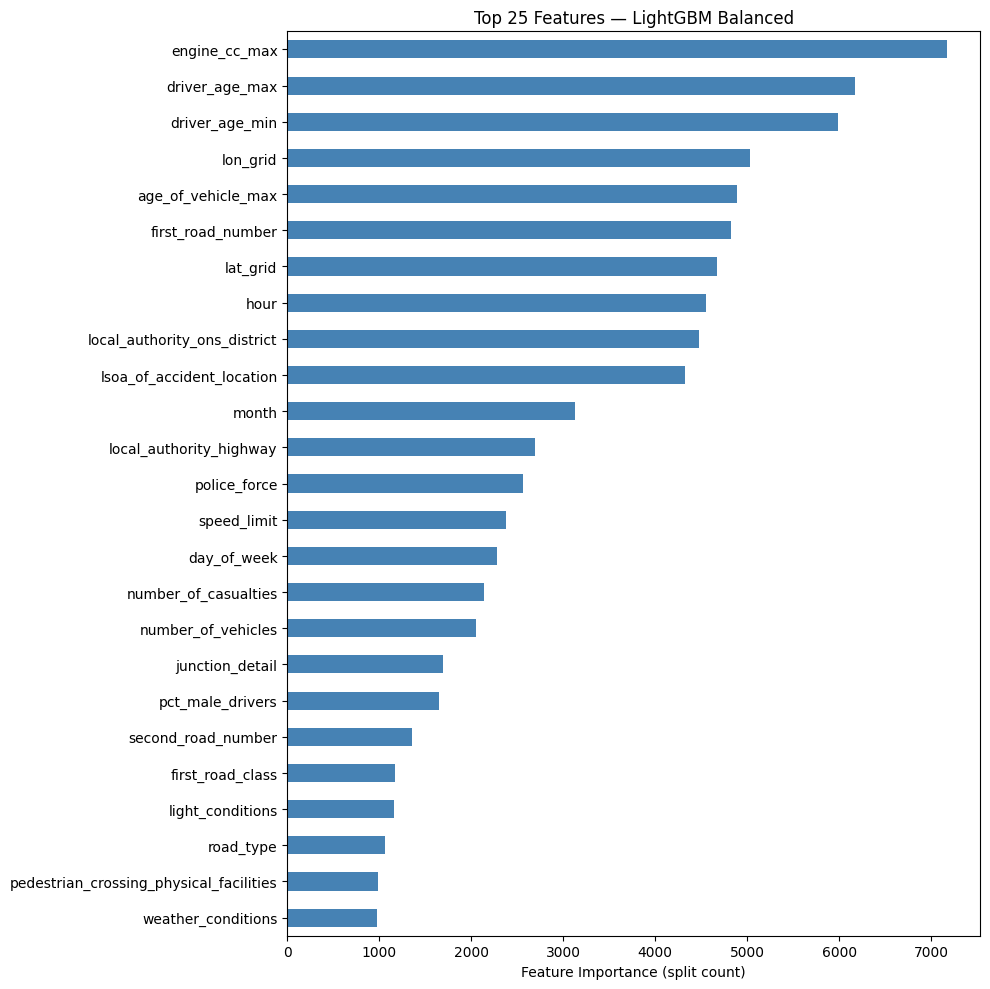

In [11]:
if lgb:
    imp = pd.Series(lgb_bal.feature_importances_, index=X.columns).sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    imp.tail(25).plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('Feature Importance (split count)')
    ax.set_title('Top 25 Features — LightGBM Balanced')
    plt.tight_layout()
    plt.show()

## Conclusions

1. **The problem is genuinely hard.** Average MI of collision features is ~0.01. No single feature strongly predicts severity from scene conditions alone.

2. **Vehicle data helps modestly.** Merging the vehicle table (motorcycle/HGV flags, driver age, engine capacity, skidding) adds features with MI comparable to the best collision features. LightGBM accuracy improves from ~55% (collision-only RF) to ~65% with the full feature set.

3. **LightGBM > LogReg/RF** for this problem. Handles class imbalance natively via `class_weight`, no SMOTE needed.

4. **Threshold optimization is essential** for the severe model. At threshold=0.02, severe recall is ~99% — the user can pick their tradeoff on the curve.

5. **Feature importance** shows driver age, engine capacity, hour of day, and geographic region matter most — all things that make intuitive sense.

**Next step:** Port this pipeline into `src/uk_road_safety/data.py` and `models.py`, retrain, and update the dashboard.